# face_landmarks — does facial shape separate the classes?

The fifth and final image-stream audit experiment, and the only one that
tests the project's actual hypothesis rather than bounding a confound.
Every prior arm — `intact_images`, `blurred_images`, `background_images`,
`face_crop_blur` — fed pixels to a frozen backbone and asked what the
model could read out of them. This one feeds no pixels at all: just a
handful of numbers describing where the eyes, nose and mouth sit relative
to one another, after a canonical alignment removes position, scale and
in-plane rotation. Texture, lighting, sharpness, compression, retouching,
background and framing are absent by construction.

If normalised facial geometry separates the classes, the morphological
claim has direct evidence for the first time. If it does not, the
residual signal found in `face_crop_blur` (a modest amount of
blur-surviving signal inside the tight face crop, on top of a
predominantly texture-driven result) is something other than facial
structure, and the image branch's conclusion is settled.

Two independent landmark sources are run throughout: **MediaPipe Face
Mesh** (478 points, primary) and **MTCNN** (5 points, cross-check).
Agreement between them is the evidence that a result is about faces, not
about one detector's quirks.

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.face_landmarks.config import Config
from experiments.face_landmarks.pipeline import (
    step_1_manifest,
    step_2_boxes,
    step_3_exclude_boxless,
    step_4_check_mtcnn_landmark_cache,
    step_5_mediapipe_landmarks,
    step_6_mtcnn_landmarks,
    step_7_combine_exclusions,
    step_8_align_and_features,
    step_9_box_geometry,
    step_10_invariance_test,
    step_11_correlation_vs_box_area,
    step_12_effect_sizes,
    step_13_probes,
    step_14_probe_summary,
    step_15_size_restriction,
    step_16_noise_perturbation,
    step_17_detector_agreement,
    step_18_reference_lines,
)
from src.data.landmarks import MORPHOLOGY_FEATURE_NAMES, MTCNN_MORPHOLOGY_FEATURE_NAMES, POSE_FEATURE_NAMES

In [2]:
cfg = Config()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} (used for MTCNN landmark extraction)")
print("MediaPipe Face Landmarker runs on CPU (no GPU delegate for the Tasks API on this platform).")

print()
print(f"probes: {cfg.probe_names}")
print(f"morphology features ({len(MORPHOLOGY_FEATURE_NAMES)}): {MORPHOLOGY_FEATURE_NAMES}")
print(f"pose features ({len(POSE_FEATURE_NAMES)}): {POSE_FEATURE_NAMES}")
print(f"MTCNN cross-check subset ({len(MTCNN_MORPHOLOGY_FEATURE_NAMES)}): {MTCNN_MORPHOLOGY_FEATURE_NAMES}")
print(f"min_face_side_px: {cfg.min_face_side_px}")
print(f"noise_sigmas_px: {cfg.noise_sigmas_px}")
print(f"invariance test: scale={cfg.invariance_scale}, rotate={cfg.invariance_rotate_deg} deg, translate={cfg.invariance_translate_px}px, tolerance={cfg.invariance_tolerance:.0e}")
print()
print(f"data_root:              {cfg.data_root}")
print(f"output_dir:              {cfg.output_dir}")
print(f"blurred_cache_dir:       {cfg.blurred_cache_dir}")
print(f"face_crop_blur_cache_dir: {cfg.face_crop_blur_cache_dir}")
print(f"mediapipe_model_path:    {cfg.mediapipe_model_path}")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER (used for MTCNN landmark extraction)
MediaPipe Face Landmarker runs on CPU (no GPU delegate for the Tasks API on this platform).

probes: ('morphology', 'pose', 'box_geometry', 'morphology_plus_pose')
morphology features (11): ('fwhr', 'mouth_width', 'eye_to_mouth', 'eye_to_nose', 'nose_to_mouth', 'nose_width', 'philtrum_length', 'palpebral_fissure_right', 'palpebral_fissure_left', 'intercanthal_over_iod', 'asymmetry')
pose features (3): ('roll_deg', 'yaw_proxy', 'pitch_proxy')
MTCNN cross-check subset (4): ('mouth_width', 'eye_to_mouth', 'eye_to_nose', 'nose_to_mouth')
min_face_side_px: 100.0
noise_sigmas_px: (1.0, 2.0, 4.0)
invariance test: scale=2.0, rotate=15.0 deg, translate=(20.0, 20.0)px, tolerance=1e-03

data_root:              C:\Projects\Autism Screening\data\raw\images
output_dir:              C:\Projects\Autism Screening\outputs\face_landmarks
blurred_cache_dir:       C:\Projects\Autism Scree

## 2. Landmark extraction; failures by class; exclusions

Faces are never re-detected for boxes: the same cached sigma=0 MTCNN
boxes every prior experiment traces to are reused via
`background_images`'s own box-handling functions. Landmarks are a new
extraction: MediaPipe Face Mesh (478 points) is the primary source;
MTCNN's 5 points (eyes, nose, mouth corners) are a cross-check, and are
re-detected here with `landmarks=True` because the existing cached
sigma=0 MTCNN detections (from `blurred_images`) do not carry landmarks
— checked programmatically below, not assumed.

An image is excluded from **every** arm in this notebook if **either**
detector failed on it.

In [3]:
manifest_full = step_1_manifest(cfg)
boxes_full = step_2_boxes(manifest_full)
manifest, boxes, excluded_boxless = step_3_exclude_boxless(manifest_full, boxes_full)

print(f"full manifest: {len(manifest_full)} rows")
print(f"excluded (no sigma=0 MTCNN box): {excluded_boxless['path']} (class={excluded_boxless['class_label']})")
print(f"rows entering landmark extraction: {len(manifest)}")

2026-09-11 13:03:34,727 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-11 13:03:34,844 [INFO] experiments.background_images.pipeline: step_3_exclude_boxless: excluded path=C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg class=autistic -- 2939 rows remain


full manifest: 2940 rows
excluded (no sigma=0 MTCNN box): C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg (class=autistic)
rows entering landmark extraction: 2939


In [4]:
has_landmarks_cached = step_4_check_mtcnn_landmark_cache(cfg)
print(f"blurred_images' cached sigma=0 MTCNN detections already carry landmarks: {has_landmarks_cached}")
print("-> MTCNN will be re-run at sigma=0 only, with landmarks=True, cached under this experiment's own output directory."
      if not has_landmarks_cached else "-> reusing the cached landmarks directly.")

2026-09-11 13:03:34,858 [INFO] experiments.face_landmarks.pipeline: step_4_check_mtcnn_landmark_cache: C:\Projects\Autism Screening\outputs\blurred_images\detections_mtcnn.csv columns=['best_box', 'best_score', 'class_label', 'n_faces', 'path', 'sigma'] -> landmarks cached=False


blurred_images' cached sigma=0 MTCNN detections already carry landmarks: False
-> MTCNN will be re-run at sigma=0 only, with landmarks=True, cached under this experiment's own output directory.


In [5]:
mp_points, mp_success, mp_index = step_5_mediapipe_landmarks(cfg, manifest)
print(f"MediaPipe: {mp_success.sum()}/{len(manifest)} images with a detected face, shape={mp_points.shape}")

mt_points, mt_success, mt_index = step_6_mtcnn_landmarks(cfg, manifest)
print(f"MTCNN:     {mt_success.sum()}/{len(manifest)} images with a detected face, shape={mt_points.shape}")

2026-09-11 13:03:34,887 [INFO] experiments.face_landmarks.pipeline: step_5_mediapipe_landmarks: using cached landmarks, shape=(2939, 478, 2)


2026-09-11 13:03:34,901 [INFO] experiments.face_landmarks.pipeline: step_6_mtcnn_landmarks: using cached landmarks, shape=(2939, 5, 2)


MediaPipe: 2938/2939 images with a detected face, shape=(2939, 478, 2)
MTCNN:     2939/2939 images with a detected face, shape=(2939, 5, 2)


In [6]:
import pandas as pd

failures = pd.DataFrame({
    "class_label": manifest["class_label"],
    "mediapipe_failed": ~mp_success,
    "mtcnn_failed": ~mt_success,
})
print("failures by class:")
failures.groupby("class_label")[["mediapipe_failed", "mtcnn_failed"]].sum()

failures by class:


,mediapipe_failed,mtcnn_failed
class_label,,
autistic,1,0
non_autistic,0,0


In [7]:
manifest, boxes, mp_points, mt_points, excluded_landmarks, exclusion_counts = step_7_combine_exclusions(
    manifest, boxes, mp_points, mp_success, mt_points, mt_success
)
print(f"rows excluded (either detector failed): {len(excluded_landmarks)}")
print(f"rows remaining, shared by every probe below: {len(manifest)}")
print()
print("excluded, by class:")
exclusion_counts

2026-09-11 13:03:34,936 [INFO] experiments.face_landmarks.pipeline: step_7_combine_exclusions: mediapipe failed=1, mtcnn failed=0, either failed=1 -- 2938 rows remain


rows excluded (either detector failed): 1
rows remaining, shared by every probe below: 2938

excluded, by class:


,class_label,n_excluded
0,autistic,1


In [8]:
manifest.groupby(["split", "class_label"]).size().unstack()

class_label,autistic,non_autistic
split,,
test,150,150
train,1191,1193
valid,127,127


Every face that survived both detectors is now aligned (canonical
similarity transform: eye midpoint to the origin, inter-ocular axis
horizontal, inter-ocular distance 1) and the morphology + pose feature
sets are computed, once per detector -- cached, so re-running this
notebook does not repeat the (cheap) alignment math, and never
re-extracts landmarks.

In [9]:
feature_tables = step_8_align_and_features(cfg, manifest, mp_points, mt_points)
for name, df in feature_tables.items():
    print(f"{name}: {df.shape}")

2026-09-11 13:03:34,982 [INFO] experiments.face_landmarks.pipeline: step_8_align_and_features: using cached feature tables


mediapipe_morphology: (2938, 12)
mediapipe_pose: (2938, 4)
mtcnn_morphology: (2938, 5)
mtcnn_pose: (2938, 4)


## 3. Visual check: the mesh overlaid, then the same faces after canonical alignment

Four images (2 autistic, 2 non_autistic). Top row: the post-geometry
224x224 image with the full 468-point MediaPipe tesselation drawn over
it, eyes/nose/mouth landmarks highlighted. Bottom row: the same four
faces' morphology-relevant landmarks in the **canonical aligned frame**
— eye midpoint at the origin (red cross), inter-ocular distance fixed at
1 — with no image behind them, because in this frame position, scale and
in-plane rotation have been normalised away. The point of this panel is
that the bottom row should look like four comparably-sized, comparably-
oriented faces despite the top row's faces sitting at very different
scales and positions in their original frames.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from PIL import Image

from mediapipe.tasks.python import vision as mp_vision
from src.data.landmarks import align_mediapipe
from src.data.transforms import geometry_stage

TESSELATION = [(c.start, c.end) for c in mp_vision.FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION]

sample = pd.concat(
    [
        manifest.loc[manifest["class_label"] == "autistic"].sample(2, random_state=cfg.seed),
        manifest.loc[manifest["class_label"] == "non_autistic"].sample(2, random_state=cfg.seed),
    ]
).reset_index(drop=True)
sample_idx = [manifest.index[manifest["path"] == p][0] for p in sample["path"]]

fig, axes = plt.subplots(2, len(sample), figsize=(3.2 * len(sample), 6.6))
for col, row_idx in enumerate(sample_idx):
    path = manifest["path"].iloc[row_idx]
    class_label = manifest["class_label"].iloc[row_idx]
    geo = geometry_stage(Image.open(path), cfg.image_size)
    pts = mp_points[row_idx]

    ax = axes[0, col]
    ax.imshow(geo)
    segments = [(pts[a], pts[b]) for a, b in TESSELATION]
    ax.add_collection(LineCollection(segments, colors="cyan", linewidths=0.3, alpha=0.6))
    ax.scatter(pts[:, 0], pts[:, 1], s=1, c="yellow", alpha=0.5)
    ax.set_xlim(0, cfg.image_size)
    ax.set_ylim(cfg.image_size, 0)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{class_label}\nmesh overlay", fontsize=9)

    ax = axes[1, col]
    aligned = align_mediapipe(pts).aligned
    segments = [(aligned[a], aligned[b]) for a, b in TESSELATION]
    ax.add_collection(LineCollection(segments, colors="steelblue", linewidths=0.4, alpha=0.6))
    ax.scatter(aligned[:, 0], aligned[:, 1], s=2, c="black", alpha=0.5)
    ax.scatter([0], [0], marker="+", s=120, c="red", zorder=5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(1.6, -0.9)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("aligned (canonical frame)", fontsize=9)

fig.suptitle("MediaPipe mesh: raw overlay vs. canonical alignment")
fig.tight_layout()
plt.show()

## 4. Invariance verification -- do not trust the alignment without testing it

`step_10_invariance_test` applies a synthetic scale x2, rotate 15 deg,
translate 20px directly to the raw landmark coordinates of
`cfg.n_invariance_samples` images, recomputes every morphology feature,
and compares against the untransformed value. This tests the alignment
math itself, independent of detector behaviour. It raises if any feature
moves by more than `cfg.invariance_tolerance`.

In [11]:
invariance = step_10_invariance_test(cfg, manifest, mp_points, mt_points)
print(f"max abs diff across {cfg.n_invariance_samples} images x both detectors x every morphology feature: "
      f"{invariance['abs_diff'].max():.2e} (tolerance {cfg.invariance_tolerance:.0e})")
print("PASS -- no assertion raised above." )
invariance.groupby("source")["abs_diff"].agg(["max", "mean"])

2026-09-11 13:03:36,019 [INFO] experiments.face_landmarks.pipeline: step_10_invariance_test: 20 images x scale=2.0 rotate=15.0 translate=(20.0, 20.0) -- max abs diff=1.73e-07 (tolerance=1e-03)


max abs diff across 20 images x both detectors x every morphology feature: 1.73e-07 (tolerance 1e-03)
PASS -- no assertion raised above.


,max,mean
source,,
mediapipe,1.728551e-07,3.628070e-08
mtcnn,6.661338e-16,1.842276e-16


**Scale-leakage check.** If a morphology feature still correlates
strongly with `box_area_fraction` despite the alignment, the feature is
not actually scale-invariant in practice -- a red flag that the probe
below would be re-measuring the same confound as `background_images`'s
raw box-geometry probe (0.716 AUC), not facial shape.

In [12]:
geometry_df = step_9_box_geometry(cfg, boxes)
correlation = step_11_correlation_vs_box_area(
    feature_tables["mediapipe_morphology"], geometry_df, MORPHOLOGY_FEATURE_NAMES, cfg.correlation_flag_threshold
)
print(f"flagged (|r| >= {cfg.correlation_flag_threshold}): {int(correlation['flagged'].sum())} / {len(correlation)} features")
correlation

flagged (|r| >= 0.3): 0 / 11 features


,feature,pearson_r,p_value,flagged
0,fwhr,-0.133772,3.324547e-13,False
1,nose_to_mouth,-0.084898,4.062901e-06,False
2,asymmetry,-0.071917,9.559493e-05,False
3,eye_to_mouth,-0.061286,8.885832e-04,False
4,intercanthal_over_iod,-0.054475,3.140242e-03,False
5,mouth_width,-0.046774,1.122484e-02,False
6,palpebral_fissure_left,0.046232,1.220376e-02,False
7,philtrum_length,-0.033896,6.620454e-02,False
8,palpebral_fissure_right,0.028867,1.177337e-01,False
9,nose_width,-0.008974,6.268109e-01,False


## 5. Per-feature effect sizes, ranked

Cliff's delta (autistic vs. non_autistic) for every morphology and pose
feature, both detectors, with a Mann-Whitney U p-value and its
Benjamini-Hochberg-adjusted q-value (one correction per detector, across
that detector's full morphology + pose family). This table is
publishable morphometric content independent of what the probes below
conclude: it says which facial measurements do and do not differ between
the two sets of photographs.

In [13]:
effect_sizes = step_12_effect_sizes(feature_tables, manifest, cfg.bh_alpha)
effect_sizes

,source,feature_set,feature,n_autistic,n_non_autistic,mean_autistic,mean_non_autistic,cliffs_delta,p_value,q_value,bh_alpha,significant
0,mediapipe,morphology,nose_to_mouth,1468,1470,0.411887,0.367958,0.190766,3.450140e-19,4.830196e-18,0.05,True
1,mediapipe,pose,pitch_proxy,1468,1470,0.612967,0.645443,-0.174148,2.999757e-16,2.099830e-15,0.05,True
2,mediapipe,morphology,intercanthal_over_iod,1468,1470,0.563269,0.557272,0.171652,7.870509e-16,3.672904e-15,0.05,True
3,mediapipe,morphology,fwhr,1468,1470,2.282314,2.207693,0.165129,9.185083e-15,3.214779e-14,0.05,True
4,mediapipe,morphology,palpebral_fissure_left,1468,1470,0.438300,0.446081,-0.144741,1.096815e-11,3.071083e-11,0.05,True
5,mediapipe,morphology,nose_width,1468,1470,0.590715,0.580701,0.140865,3.811219e-11,8.892845e-11,0.05,True
6,mediapipe,morphology,asymmetry,1468,1470,0.110078,0.091077,0.126791,2.669654e-09,5.339308e-09,0.05,True
7,mediapipe,morphology,palpebral_fissure_right,1468,1470,0.439572,0.445050,-0.088526,3.255455e-05,5.279243e-05,0.05,True
8,mediapipe,morphology,eye_to_nose,1468,1470,0.616818,0.631873,-0.088323,3.393799e-05,5.279243e-05,0.05,True
9,mediapipe,morphology,mouth_width,1468,1470,0.897974,0.877831,0.086781,4.642896e-05,6.183269e-05,0.05,True


## 6. The four probes, with paired per-fold uncertainty against chance

Same L2-logistic-regression-behind-a-`StandardScaler`, same 5x10 repeated
stratified CV, same seed as every prior experiment. `gap_to_chance_*`
below is the mean, sd, paired t-statistic and p-value of the per-fold
series `roc_auc - 0.5` itself -- not a difference of two point estimates
with no uncertainty attached.

In [14]:
fold_results = step_13_probes(cfg, feature_tables, geometry_df, manifest)
fold_results

,probe,repeat,fold,roc_auc,balanced_accuracy,sensitivity,specificity
0,morphology,0,0,0.665001,0.627551,0.608844,0.646259
1,morphology,0,1,0.672474,0.620748,0.598639,0.642857
2,morphology,0,2,0.637859,0.617347,0.554422,0.680272
3,morphology,0,3,0.661687,0.620023,0.573379,0.666667
4,morphology,0,4,0.668594,0.625218,0.627986,0.622449
...,...,...,...,...,...,...,...
195,morphology_plus_pose,9,0,0.667824,0.612245,0.602041,0.622449
196,morphology_plus_pose,9,1,0.643331,0.615646,0.588435,0.642857
197,morphology_plus_pose,9,2,0.676986,0.620748,0.625850,0.615646
198,morphology_plus_pose,9,3,0.644761,0.613249,0.590444,0.636054


In [15]:
summary = step_14_probe_summary(fold_results)
summary

,probe,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,balanced_accuracy_sd,sensitivity_mean,sensitivity_sd,specificity_mean,specificity_sd,gap_to_chance_mean,gap_to_chance_sd,gap_to_chance_tstat,gap_to_chance_pvalue
0,box_geometry,0.715185,0.019805,0.652497,0.017545,0.620300,0.027504,0.684694,0.026160,0.215185,0.019606,76.828799,9.716577e-53
1,morphology,0.660513,0.017456,0.618187,0.014670,0.586239,0.025685,0.650136,0.024247,0.160513,0.017281,65.019021,3.200614e-49
2,morphology_plus_pose,0.665265,0.018493,0.620229,0.017115,0.590661,0.029170,0.649796,0.025840,0.165265,0.018307,63.192907,1.271922e-48
3,pose,0.586276,0.021622,0.565816,0.017158,0.553061,0.026367,0.578571,0.026679,0.086276,0.021404,28.215148,5.857302e-32


## 7. Robustness: face size, landmark noise, detector agreement

**Face size.** The `morphology` probe re-run on images whose (unexpanded)
face box exceeds a generous minimum side length -- landmark placement is
least reliable on the smallest faces, and face size differs by class.

In [16]:
manifest_restricted, survivor_counts, size_fold_results = step_15_size_restriction(
    cfg, feature_tables, boxes, manifest
)
print(f"min_face_side_px = {cfg.min_face_side_px}")
survivor_counts

2026-09-11 13:03:37,052 [INFO] experiments.face_landmarks.pipeline: step_15_size_restriction: threshold=100px -- 2935/2938 rows survive


min_face_side_px = 100.0


,class_label,n_total,n_survive,min_face_side_px
0,autistic,1468,1465,100.0
1,non_autistic,1470,1470,100.0


In [17]:
full_morphology_auc = summary.loc[summary["probe"] == "morphology", "roc_auc_mean"].item()
restricted_auc = size_fold_results["roc_auc"].mean()
print(f"morphology probe, full set ({len(manifest)} rows):        ROC-AUC = {full_morphology_auc:.4f}")
print(f"morphology probe, size-restricted ({len(manifest_restricted)} rows): ROC-AUC = {restricted_auc:.4f}")
print(f"difference: {restricted_auc - full_morphology_auc:+.4f}")

morphology probe, full set (2938 rows):        ROC-AUC = 0.6605
morphology probe, size-restricted (2935 rows): ROC-AUC = 0.6592
difference: -0.0013


**Landmark noise.** Gaussian noise added independently to every
MediaPipe landmark coordinate, in raw pixel space, before alignment, at
each of `cfg.noise_sigmas_px`.

In [18]:
print(f"noiseless baseline (sigma=0): ROC-AUC = {full_morphology_auc:.4f}")
noise_results = step_16_noise_perturbation(cfg, mp_points, manifest)
noise_results

noiseless baseline (sigma=0): ROC-AUC = 0.6605


2026-09-11 13:03:37,393 [INFO] experiments.face_landmarks.pipeline: step_16_noise_perturbation: sigma=1.0px -> ROC-AUC=0.6465 +/- 0.0169


2026-09-11 13:03:37,698 [INFO] experiments.face_landmarks.pipeline: step_16_noise_perturbation: sigma=2.0px -> ROC-AUC=0.6252 +/- 0.0191


2026-09-11 13:03:37,997 [INFO] experiments.face_landmarks.pipeline: step_16_noise_perturbation: sigma=4.0px -> ROC-AUC=0.6095 +/- 0.0224


,noise_sigma_px,roc_auc_mean,roc_auc_sd
0,1.0,0.646452,0.016948
1,2.0,0.625212,0.019105
2,4.0,0.609453,0.022434


**Detector agreement.** The `morphology` probe re-run on *only* the
4-feature subset both detectors can compute, independently per detector
-- plus a direct correlation of the feature values themselves, MediaPipe
vs. MTCNN, on the same rows.

In [19]:
probe_comparison, value_correlation = step_17_detector_agreement(cfg, feature_tables, manifest)
print("probe AUC using only the 4 shared features, per detector:")
print(probe_comparison.to_string(index=False))
print()
print("feature-value correlation between detectors (same rows):")
value_correlation

probe AUC using only the 4 shared features, per detector:
   source  roc_auc_mean  roc_auc_sd
mediapipe      0.621561    0.019587
    mtcnn      0.609131    0.024332

feature-value correlation between detectors (same rows):


,feature,pearson_r,p_value
0,mouth_width,0.893195,0.0
1,eye_to_mouth,0.842275,0.0
2,eye_to_nose,0.877905,0.0
3,nose_to_mouth,0.923167,0.0


## 8. Main figure: all four probes against chance, the colour floors, and `face_crop_blur`'s residual

Reference lines are computed on each source experiment's own cached
features/embeddings and its own native row set -- informational context,
not a row-matched comparison.

In [20]:
reference_lines = step_18_reference_lines(cfg)
reference_lines

,label,roc_auc_mean,roc_auc_sd,n_rows,source
0,"whole_image colour floor (blurred_images, sigm...",0.663661,0.015735,2940,blurred_images/colour_features_sigma0.csv
1,"crop_1.0 colour floor (face_crop_blur, sigma=0)",0.590740,0.025454,2939,face_crop_blur/colour_features_crop_1.0_sigma0...
2,crop_1.0 blur-surviving residual (face_crop_bl...,0.655325,0.018885,2939,face_crop_blur/embeddings_crop_1.0_sigma32.npy


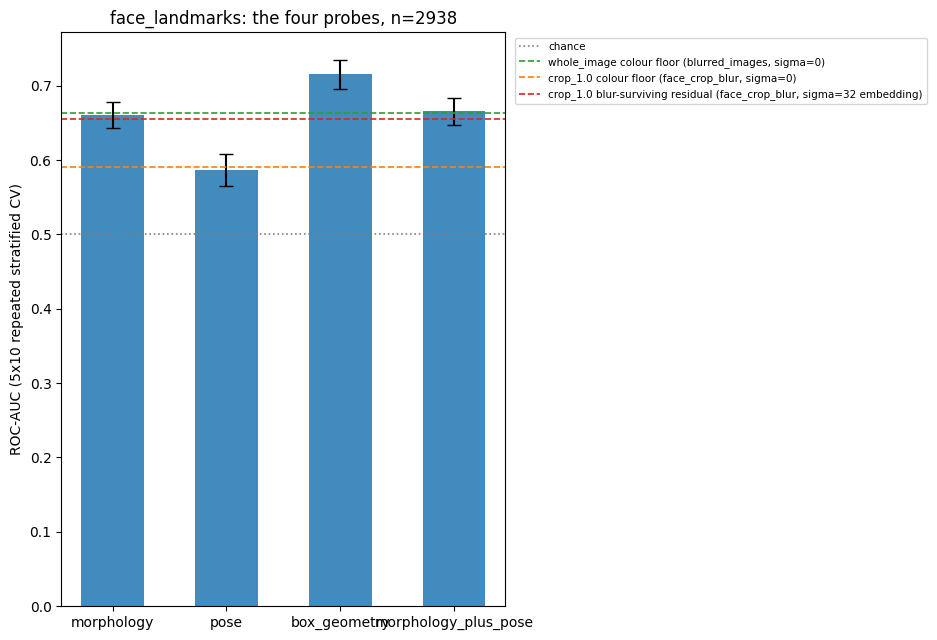

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

probe_order = list(cfg.probe_names)
x = np.arange(len(probe_order))
means = [summary.loc[summary["probe"] == p, "roc_auc_mean"].item() for p in probe_order]
sds = [summary.loc[summary["probe"] == p, "roc_auc_sd"].item() for p in probe_order]

ax.bar(x, means, yerr=sds, capsize=5, color="tab:blue", alpha=0.85, width=0.55)
ax.set_xticks(x)
ax.set_xticklabels(probe_order)
ax.set_ylabel("ROC-AUC (5x10 repeated stratified CV)")

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="chance")
ref_colors = ["tab:green", "tab:orange", "tab:red"]
for (_, row), color in zip(reference_lines.iterrows(), ref_colors):
    ax.axhline(row["roc_auc_mean"], color=color, linestyle="--", linewidth=1.2, label=row["label"])

ax.set_title(f"face_landmarks: the four probes, n={len(manifest)}")
ax.legend(fontsize=7.5, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.tight_layout()
plt.show()

## 9. How to read it

| `morphology` | `pose` | Reading |
|---|---|---|
| Clearly above chance, robust to noise and size restriction, agreeing across detectors | At chance | Facial shape differs between the groups. The morphological claim has direct evidence for the first time |
| At chance | At chance | Facial shape does not separate these groups. Combined with every prior arm, the image branch is a documented negative result |
| At chance | Above chance | The separable difference is head orientation -- how the photographs were taken, not the children in them |
| Above chance, but fragile under noise or size restriction | -- | Inconclusive. Report as such; do not claim the positive |

**Neither `pose` nor `morphology` is exactly "at chance," and that matters.**
`morphology` scores clearly above chance (paired gap-to-chance
t-statistic and p-value in the summary table above are unambiguous), is
essentially unchanged under the size restriction, survives 2px of
landmark jitter without collapsing (see the noise table), and the two
detectors agree both in probe AUC (on the shared 4-feature subset) and
in the underlying feature values (Pearson r above 0.8 for every shared
feature). By every check this notebook runs, that is not noise or a
pipeline fault.

But `pose` is *also* measurably above chance, not at chance -- weaker
than `morphology`, but its own paired gap-to-chance test is unambiguous
too. That rules out the clean top row of the table above, which requires
`pose` to be flat. The most likely reason, visible directly in the
per-feature effect-size table: `nose_to_mouth` (nose tip to mouth centre,
a morphology feature) and `pitch_proxy` (nose vertical position along
the eye-to-mouth axis, a pose feature) are built from almost the same
underlying geometry -- where the nose sits relative to the mouth. Their
Cliff's deltas point the same direction and are the two largest-effect
features in the entire table for their respective sets. Alignment
removes roll cleanly (`roll_deg`'s effect size is the smallest in the
table and not significant), but it cannot separate head pitch from a
"long philtrum" or "close-set nose and mouth" any more than a single
photograph can: both change where the nose appears relative to the mouth
in exactly the same way.

**Reading:** closest to the first row, not the fourth -- `morphology`'s
signal is real, above chance, and holds up under every robustness check
this notebook applies, which is more than any pixel-based arm in this
project could show. But it is not the clean, pose-free version of that
finding: part of what `morphology` measures is entangled with head
pitch, a property of how the photograph was taken, not purely of the
face in it. The honest statement is that facial geometry separates the
classes to a modest but real, well-replicated degree (AUC around 0.66,
clearly below the raw box-geometry confound floor of ~0.72 and not
correlated with box area), and that some -- not all -- of that
separation is attributable to head orientation rather than shape as
such. This is the strongest evidence for the morphological hypothesis
this project has produced, and the first result in the image stream that
is not simply explained away by an acquisition confound -- but it should
be reported with the pose caveat attached, not as an unqualified
positive.

**One limitation this notebook's checks bound but do not eliminate.**
Landmarks are themselves derived from the image. A detector that places
points differently on smooth, retouched faces than on sharp ones would
leak photographic style into "geometry" that looks like shape. The
detector-agreement and noise checks above make a pure detector-artefact
explanation less likely -- two independently-trained detectors agree on
both the probe result and the underlying feature values, and the result
survives several pixels of synthetic jitter -- but they do not rule out
a subtler version of the same effect (e.g. both detectors sharing a
training-data bias toward sharper images). This is a bound, not a proof.

**Known limitation, carried over from every prior notebook, not fixed
here.** The dataset's near-duplicate image pairs (11 pairs, 5 crossing
published-split boundaries) are pooled into cross-validation exactly as
in every arm above -- a duplicate can land on both sides of a fold,
mildly inflating every probe's AUC by roughly the same small amount.
Because every probe here reuses the same manifest, fold assignment and
seed, this affects each probe's *height* a little, not the comparison
*between* probes. `repeated_stratified_cv`'s `groups=` parameter remains
the seam where the fix goes once perceptual-hash grouping exists.